# 2. Statistical Learning

For questions refer ISLP textbook at page 63.

## Notes

* Input variables are typically denoted by the symbol X representing a vector and the output is denoted by the symbol Y.
* Suppose we observe a quantitative response Y and p different inputs, $X_1$, $X_2$, $X_3$, ... ,$X_p$, we assume that a relationship exists which can be mathematically represented as:
    Y = f(X) + $\epsilon$
* Here f is some fixed but unknown function of the input vector X and $\epsilon$ is a random error term, which is independent of X and has mean zero. In this formulation, X represents the systematic information X provides about the output Y.
* In essence, statistical learning refers to a set of approaches for estimating f.
* *Prediction* and *Inference* are the two main motivations for trying to estimate f. 

### Prediction

* In many situations, a set of inputs X are readily available, but the output Y cannot be easily obtained. In this setting Y can be predicted using: **$\hat{Y}$ = $\hat{f}$(X)**
* Here, $\hat{f}$ represents our estimate for f and $\hat{Y}$ represents the resulting prediction for Y.
* In this setting, one is not typically concerned with the exact form of f. It gets treated like a *black-box*. How it makes a prediction does not interest us, only that the predictions it makes are accurate.
* For example, trying to predict a patient's rick of having an adverse reaction to a particular drug using characteristics of their blood sample as input. 
* The accuracy of $\hat{Y}$ depends on **reducible** and **irreducible** error. In general $\hat{f}$ will not be a perfect estimate for f. This results in some error. Luckily, this error can be reduced with better modelling and using a larger training data set. In other words, it is reducible. On the other hand, since Y also depends on a random error term $\epsilon$ which does not feature in our function for $\hat{Y}$, we have an error of a different kind. Irreducible error. There is nothing anyone can do about it. It marks the maximum achievable accuracy for any model trying to estimate Y.
* The focus of this book is on techniques for estimating f with the aim of minimising the recudible error.

### Inference

* In this setting, we are interested in understanding the association between Y and the input vector X.
* We do not treat $\hat{f}$ as a *black-box*. We care about its form. 
* We are interested in questions like these:

    1. *Which predictors are associated with the response?*
    2. *What is the relationship between the response and each predictor?*
    3. *Can the relationship between Y and each predictor be adequately summarised using a linear equation, or is the relationship more complicated?*
* For example, a company trying to understand which advertising media (TV, radio, or newspaper) are associated with sales. The focus here is inference. The exact form of $\hat{f}$ is important to them.

### How do we estimate f?

* The goal is to discover a function $\hat{f}$ such that Y $\approx$ $\hat{f}$(X) for any observation(X,Y). Here X is a p-dimensional vector. It is convenition to denote the number of input variables with p and the number of data points with n.
* Broadly, most statistical learning methods for this task can be characterised as either **parametric** or **non-parametric**
* Parametric methods involve a two-step model-based approach:

    1. Assume the functional form (shape) of f.
    2. Train the model by using training data to estimate model parameters.
* For example, we might assume that f is linear. That is it has the form: f(X) = $\beta_0$ + $\sum_{i=1}^{p}$ $\beta_iX_i$. This assumption makes life a lot easier. Now, instead of having to estimate an entirely arbitrary p-dimensional function f(X), we only need to estimate the p+1 coefficients $\beta_0$, $\beta_1$, $\beta_2$, ... ,$\beta_p$. *Oridinary least squares* is a common approach for fitting the model.
* **Advantage:** Easier to estimate a set of parameters than it is to fit an arbitrary function f. 
* **Disadvantage:** The model chosen will usually not match the true unknown form of f resulting in poor fitting.
* Non-parametric methods do not make explicit assumptions about the functional-form of f. Instead, they seek an estimate of f that gets as close to the data points as possible without being to rough or wiggly. Example: thin plate spline  (discussed in chapter 7), K-nearest neighbours classification.
* **Advantage:** Potential to accurately fit a wider range of shapes for f since no assumption is made about the form of f. 
* **Disadvantage:** Since they do not reduce the problem of estimating f to a small number of parameters, a very large number of observations is required in order to obtain an accurate estimate for f.

### Accuracy versus Interpretability Trade-Off

* 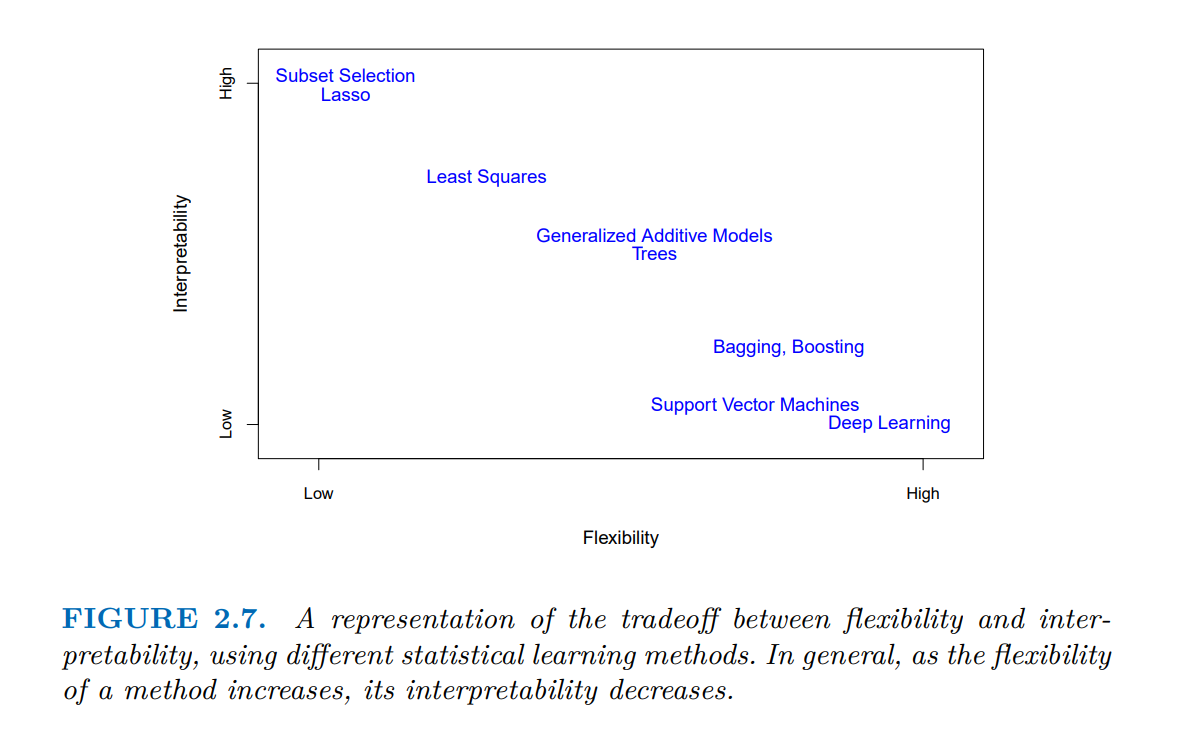

* *Why would on ever choose to use a more restrictive statistical learning method instead of a very flexible approach?*
* Restrictive models, due to their simplicity, are better suited for interpretability. Therefore, when interpretability is the primary goal, the choice of a restrictive model is not surprising. 
* Furthermore, even in a scenario where prediction is the main goal - for example, predicting the price of a stock a week from now - restrictive methods might outperform extremely flexible methods. This is because, with increasing flexibility comes the risk of overfitting. This is a situation where the model has modelled the random error (noise) in the training data set. It will perform extremely well on the data it was trained on, but this performance will not extend to new data.

### Supervised vs Unsupervised Learning

* **Supervised Learning**: We are have data with predictors and associated responses. We fit a model that relates the predictors to the responses, with the aim of accurately predicting the response for future observations (prediction focus) or better understanding the relationship between the predictors and responses (interpretability focus). Examples are linear regression, logistic regression, and Generalised Additive Models (GAMs).
* **Unsupervised Learning**: This is a more challenging situation. For each observation, we have a vector of measurements but no associated response y_i. It gets its name because we lack a response variable to supervise the analysis. Cluster analysis is a common unsupervised learning method where the goal is to ascertain whether the observations fall into relatively distinct groups.

### Assessing Model Accuracy

* *There is no free lunch in statistics:* no one method dominates all others over all possible data sets. On a particular data set, one specific method may work best, but some other method may work better on a similar but different data set. Assessing model accuracy allows us to identify the method that produces the best results in a given situation. 
* **Quality of Fit Measurement**: Assessing how well a model's predictions match the observed data. It is a measure of "closeness" of the predicted response value for a given observation to the true response value for that observation.
* In the regression setting **Mean Squared Error (MSE)** is the most commonly used measure. It is calculated as: 

    $$\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{f}(x_i))^2$$
* A model ($\hat{f}$) with high accuracy will have a low MSE as the predictions ($\hat{f}(x_i)$) will be close to their corresponding true response outcomes ($y_i$).
* **Goal: Minimise MSE on test data.** While MSE of a model assessed on training data is indicative of goodness of fit, it is of greater interest to us to assess MSE on previously unseen data that was not used to train the model. There is no guarantee that the method with the lowest training MSE will also have the lowest test MSE.
* For example, let us consider a regression model that predicts stock price a week into the future. This model was trained on market data from the past decade. We are more interested in next week's price forecast than in how accurately the model explains past prices. We might want to test the model for a couple of months on "live" market data to check that it works well enough before deploying it.
* 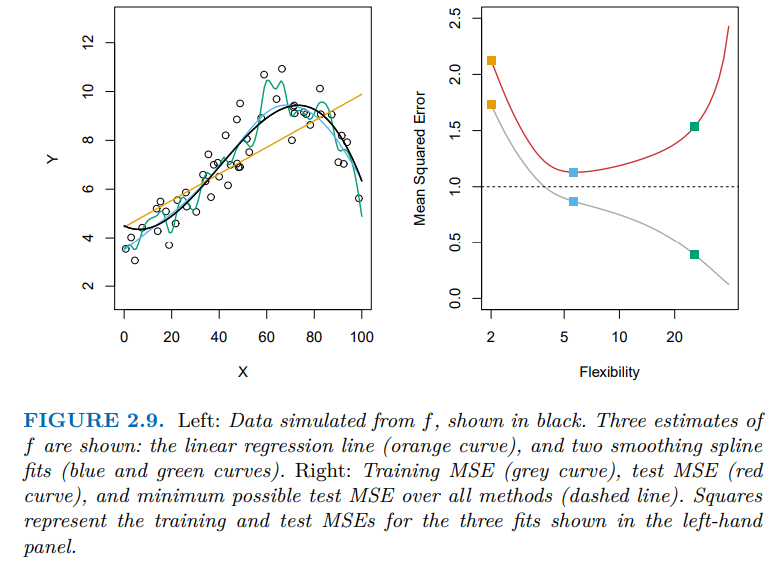
* In the right-hand panel of the figure above, as the flexibility of the statistical learning method increases, we observe a monotone decrease in the training MSE and a U-shape in the test MSE. This is a fundamental property of statistical learning that holds regardless of the particular data set at hand and regardless of the statistical method being used.
* **Overfitting**: The situation where a method yields a small training MSE but a large test MSE, and where using a less flexible model would reduce the test MSE.
* This happens because the method is working too hard to find patterns in the training data and ends up picking up some false patterns caused by random chance rather than by the true properties of the unknown function f.
* **Cross-Validation** (concept discussed in chapter 5) is a method used in practice for estimating test MSE from training data.

### Bias-Variance Tradeoff

* The "U'shape" observed in test MSE with changing model flexibility is a result of two competing properties of statistical learning methods: **bias** and **variance**.
* The expected test MSE can be decomposed into the sum of three quantities:
    1. the variance of $\hat{f} ({x_0})$,
    2. the squared bias of $\hat{f} ({x_0})$, and
    3. the variance of the error terms $\epsilon$

* **$$ E(y_0 - \hat{f}(x_0))^2 = Var(\hat{f}(x_0)) + [Bias(\hat{f}(x_0))]^2 + Var(\epsilon)$$**
* The equation above tells us that to minimise expected error, we must select a statistical learning method that simultaneously achieves *low variance* and *low bias*.
* Both variance and squared bias are non-negative quantities. Hence, the expectation of test MSE can never lie below $ Var(\epsilon)$ which represents the variance of irreducible error.
* **Variance** refers to the amount by whichy $\hat{f}$ would change if we estimated it using a different training data set. In general, more flexible statistical methods have higher variance.
* **Bias** refers to the error that is introduced by approximating a real-life problem, which may be extremely complicated, by a much simpler model. For example, linear regression assumes that there is a linear relationship betwenn Y and X_1, X_2, X_3, ... ,X_p. It is unlikely that any real-life problem truly has such a simple linear relationship, and so performing linear regression will undoubtedly result in some bias in the estimate of f. Generally, more flexible methods result in less bias.
* As we use more flexible methods, the variance will increase and the bias will decrease. The relative change of these quantities determines whether MSE increases or decreases. 
* This Bias-Variance tradeoff is a recurring theme of this book. We seek to find a statistical method for which both the variance and the squared bias are low. 

### The Classification Setting

* **Error rate** is the most common method for quantifying the accuracy of classification models. It is calculated as:
$$ \frac{1}{n} \sum_{i=1}^{n} I(y_i \neq \hat{y_i}) $$

* In the function above, I is an indicator random variable. It equals 1 when the conditional in the parenthesis is true and 0 otherwise. Therefore, it is a tool to count every error that the model $\hat{f}$ makes. The total number of errors is then averaged by dividing by the number of predictions made (n).

* The Bayes' classifier is a very simple clasifier that assigns each observation to the most likely class, given its predictor values. In mathematical terms, the model assigns a test observation with predictor vector x_0 to the class j for which $ Pr(Y = j|X = x_0) $ is the largest. 
* In a two class problem, the Bayes classifier corresponds to prediciting class one if $Pr(Y=1|X=x_0) > 0.5$, and class two otherwise.
* The Bayes classifier produces the lowest possible test error rate, called the *Bayes error rate*. This fact can be mathematically proven. 
* Since the Bayes classifier always choses the class for which $ Pr(Y=j | X = x_0) $ is the largest, the error rate will be: $1 - max_j Pr(Y=j|X=x_0) $. In general, te overall Bayes error rate is given by: 
$$ 1 - E(max_j Pr(Y=j|X)) $$
* The Bayes error rate is analogous to the irreducible error discussed earlier.








## *Conceptual Problems*


### Question 1

(a) When the sample size n is extremely large and p is small, flexible methods can be expected to perform better than inflexible methods. The large number of observations will reduce the risk of the model picking up on and using background noise in making its predictions. This because a large number of observations reduces the variance. Hence, using a optimally flexible model can be expected to minimise test MSE.

(b) When p is large and n is small, using a flexible model will likely result in a perfect fit on the training data. Hence, the training MSE will be near zero. However, this will not translate well to future observations that were not used in model fitting. Consequently, the test MSE is likely to be extremely high.

(c) When the true relationship between the predictors and response is highly non-linear, fitting a rigid model will not capture the relationship well. This is a case of using a biased model.

(d) When the variance of the error terms is extremely high. An inflexible model is likely to outperform a flexible one as the risk of picking up relationships in the random noise is reduced.

### Question 2

(a) This is a regression problem. Since the objective is to understand the factors affecting CEO salary, we are most interested in inference. n is 500 and p is 3.

(b) This is a classification problem. The objective is prediction. n is 20 and p is 13.

(c) This is a regression problem. The objective is prediction. n is 52 and p is 3.

### Question 3

(a)

![Bias-Variance Sketch](figures\2_Q3.png)

(b) 

**Bias**: As flexibility increases, the assumption of the nature of the relationship between independent and dependent variables weakens. This causes bias to decrease.

**Variance**: As flexibility increases, the model is able to fit each data point better. As a result, it begins capturing more of the underlying noise from the training data set. This causes variance to increase.


**Test MSE**: As flexibility increases, the test MSE decreases up to a point due to decreasing bias. Beyond this point, the increasing variance has a greater effect and causes test MSE to increase. This results in a characteristic 'U' shape.

**Training MSE**: As flexibility increases, training MSE decreases monotonically until it reaches zero. This is because with increased flexibility, the model curve is able to pass through each point in the training data set perfectly.

**Irreducible error**: This is the level of best theoretical test MSE that can be achieved. It is limited by the random error terms which is independent of the independent variables. Hence, the independent variables provide us no information about this error. 

### Question 4

(a) Three real-life applications of classification:

1. Predicting the winner of a tennis match for sports betting. The response is the binary outcome of the game (P1 Win/P2 Win). The predictors can be past head-to-head record, recent form, court surface, current world ranking, and handedness. The goal is prediction; we care about who will likely win so we can place a bet, the factors affecting the win do not concern us. 

2. Understanding what factors increase the probabilty of scoring a goal from a corner kick. The response is the binary outcome of the corner kick (goal/no goal). The predictors can be corner taker, near/far post, attacking team formation, defensive team formation, current score, and time remaining. The goal here is inference. Coaching teams try to understand what factors increase the chances of goals coming from corner kicks.

3. Classifying football players are being 'at-risk' or healthy based on training load and recovery metrics. The predictors are metrics like sleep duration, sleep quality, training load in the past week, training load in the past day, resting heart rate, and heart rate variability. The goal here is prediction. Sports science teams use models such are this to determine whether or not it is safe to push a player hard during training or take it easy on him.

(b) Three real-life applications of regression:

1. Predicting the energy expenditure of footballers using data collected from wearable devices such as a Capapult GPS unit. The predictors will be accelerometer data, GPS data, and heart rate data. The goal here is prediction as accurate estimation of energy expenditure will be valuable in training load monitoring.

2. Predicting the price of a house based on factors like locality, number of bedrooms, area, median income of suburb, and proximity to shopping centre. The goal is here is prediction accuracy as this can help real estate agents price properties.
 
3. Predicting the density of corals in particular locations of the sea using data like depth, mean tide height, water quality, salinity, marine traffic, proximity to land, and type of sea floor. This problem is not aimed at prediction, rather the idea is to learn what conditions favour coral growth and maturation. Marine biologists might use the findings to choose where to focus their efforts in artificial reef regeneration.

(c) Three real-life applications of cluster analysis:

1. Identifying whether footballers in a particular team can be divided into distinct groups based in training and recovery data. This can help teams tailor their training and recovery approaches for each group.

2. Learning whether students in a class can be categorised into various groups based on academic performance, subjects chosen, age, gender, and distance between home and school. This can help teachers better cater to the needs of each student group.

3. Categorising netball players into the position they mainly play. Netball players often play more than one position. Using cluster analysis with seven clusters will likely assign player to a positional cluster. This will use information like minutes played in each position, goals scored, blocks, intercepts, assists, and minutes played.

### Question 5

**Advantages**

Very flexible methods reduce bias as they make little to no assumption about the nature of the underlying relationship between predictors and outcome. Therefore, they are effective in capturing non-linear relationships. Additionally, when the goal is prediction rather than interpretation, one is justified in choosing a better performing model over one that is easier to interpret. 

When there are a lot of observations relative to the number of predictors, using a more flexible method is preferred.

**Disadvantages**

When the number of observations are low and the number of predictor variables are large, using a very flexible method will artificially boost training performance by overfitting. This high performance will not carry over to new data. Therefore, in this situation using a less flexible method is recommended. Additionaly, if the goal is interpretation, less-flexible methods are preferred as enable easy interpretation.

### Question 6

**Parametric Approach**

A parametric statistical learning approach assumes that the nature of the relationship between independent and dependent variables is of a certain functional form (linear, quadratic, cubic, etc). This assumption increases bias and can result in poor model performance if the true distribution pattern is far from this assumed form. On the other hand, making this assumption enables statisticians to implement parametric methods to the data. This enables calculation of statistical power and p-values which are very useful in distinguishing whether an observed relationship or pattern is due to chance or reflective of a true relationship. Model interpretation is the biggest advantage of using a parametric approach.

**Non-Parametric Approach**

This approach makes no assumption about the nature of the relationship between dependent variable. Consequently, the bias is low and the model is more flexible. On the other hand, if the chosen model is too flexible, overfitting can occur which will result in extremely good training performance but poor test performance. However, in cases where the training data is large, non-parametric approaches will likely perform better than parametric approaches. However, this comes at the cost of interpretability as non-parametric methods are generally difficult to interpret.

### Question 7

(a) 
| Observation | Euclidean distance to test point (0,0,0) |
| --- | --- |
|(0,3,0)|3|
|(2,0,0)|2|
|(0,1,3)|$\sqrt{10}$|
|(0,1,2)|$\sqrt{5}$|
|(-1,0,1)|$\sqrt{2}$|
|(1,1,1)|$\sqrt{3}$|

(b) 
The prediction with K = 1 will be the same as the closest point to the test point. The closest point to (0,0,0) is (-1,0,1) and the outcome variable in that case was **Green** Hence, our prediction for (0,0,0) with K = 1 is **Green**.

(c)
The prediction with K = 3 will be the majority outcome in the three closest points to (0,0,0). (-1,0,1), (1,1,1), and (2,0,0) are the three closest points and their outcomes are **Green**, **Red**, and **Red** respectively. Hence, with K = 3 our prediction for (0,0,0) will be **Red**.

(d)
If the Bayes decision boundary is highly non-linear, the *best* value for K will be small. This is because a smaller value of K ensures the classification of the point depends on a small surrounding outcome region as opposed to a large K. This will increase the flexibility of the K-nearest neighbours model's decision boundary.


## *Applied Problems*

### Question 8

(a) Read the college data into Python using the *read_csv* function. Call the loaded data **college**.  Unlike what ISLP recommends, I am using Polars instead of Pandas as it is much better when working with large datasets.

In [1]:
import polars as pl

college = pl.read_csv(r"data\college.csv")

(b) Run a new cell with just the code *college* in it. You will notice that the first column is unnamed. We want to name this column and set it as the index of the dataframe. However, since I am using Polars, there is no concept of an index here unlike in Pandas.

In [2]:
# Running college to see whether the first column is unnamed.
college

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
str,str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,i64,i64,i64
"""Abilene Christian University""","""Yes""",1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
"""Adelphi University""","""Yes""",2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
"""Adrian College""","""Yes""",1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
"""Agnes Scott College""","""Yes""",417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
"""Alaska Pacific University""","""Yes""",193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Worcester State College""","""No""",2197,1515,543,4,26,3089,2029,6797,3900,500,1200,60,60,21.0,14,4469,40
"""Xavier University""","""Yes""",1959,1805,695,24,47,2849,1107,11520,4960,600,1250,73,75,13.3,31,9189,83
"""Xavier University of Louisiana""","""Yes""",2097,1915,695,34,61,2793,166,6900,4200,617,781,67,75,14.4,20,8323,49


In [3]:
# First column is unnamed. Renaming it to "College".
college = college.rename({college.columns[0]: "College"})

(c) Use the describe() method to produce a numerical summary of the variables in the data set.

In [4]:
college.describe()

statistic,College,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""","""777""","""777""",777.0,777.0,777.0,777.0,777.0,777.0,777.0,777.0,777.0,777.0,777.0,777.0,777.0,777.0,777.0,777.0,777.0
"""null_count""","""0""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",null,null,3001.638353,2018.804376,779.972973,27.558559,55.796654,3699.907336,855.298584,10440.669241,4357.526384,549.380952,1340.642214,72.660232,79.702703,14.089704,22.743887,9660.171171,65.46332
"""std""",null,null,3870.201484,2451.113971,929.17619,17.640364,19.804778,4850.420531,1522.431887,4023.016484,1096.696416,165.10536,677.071454,16.328155,14.722359,3.958349,12.391801,5221.76844,17.17771
"""min""","""Abilene Christian University""","""No""",81.0,72.0,35.0,1.0,9.0,139.0,1.0,2340.0,1780.0,96.0,250.0,8.0,24.0,2.5,0.0,3186.0,10.0
"""25%""",null,null,776.0,604.0,242.0,15.0,41.0,992.0,95.0,7320.0,3597.0,470.0,850.0,62.0,71.0,11.5,13.0,6751.0,53.0
"""50%""",null,null,1558.0,1110.0,434.0,23.0,54.0,1707.0,353.0,9990.0,4200.0,500.0,1200.0,75.0,82.0,13.6,21.0,8377.0,65.0
"""75%""",null,null,3624.0,2424.0,902.0,35.0,69.0,4005.0,967.0,12925.0,5050.0,600.0,1700.0,85.0,92.0,16.5,31.0,10830.0,78.0
"""max""","""York College of Pennsylvania""","""Yes""",48094.0,26330.0,6392.0,96.0,100.0,31643.0,21836.0,21700.0,8124.0,2340.0,6800.0,103.0,100.0,39.8,64.0,56233.0,118.0


(d) Produce a scatterplot matrix of the first columns [Top10perc, Apps, Enroll]. While ISLP uses Pandas' inbuilt plotting feature to do this, I will use plotly express as it works better with polars. 

In [5]:
import plotly.express as px

C = ["Top10perc", "Apps", "Enroll"]
fig = px.scatter_matrix(
    data_frame=college,
    dimensions=C,
    opacity=0.5,
    title="Scatterplot Matrix of Top10perc, Apps, and Enroll",
)

fig.update_layout(width=600, height=600)

fig.show()

del C

(e) Produce side-by-side boxplots of Outstate versus Private.

In [6]:
fig = px.box(
    data_frame=college,
    x="Private",
    y="Outstate",
    title="Boxplot of Out-of-state Tuition by Private vs. Public Colleges",
)

fig.update_layout(width=600, height=400)

fig.show()

(f) Create a new qualitative variable called *Elite* by binning the Top10perc variable into two groupd based on whether or not the proportion of students coming from the top 10% of their high school classes exceeds 50%. The Elite column can contain either "Yes" or "No". Then use the value_counts method to see how many elite universities there are. Finally, create side-by-side boxplots of Outstate versus elite.

In [7]:
college = college.with_columns(
    pl.when(pl.col("Top10perc") > 50)
    .then(pl.lit("Yes"))
    .otherwise(pl.lit("No"))
    .alias("Elite")
)

In [8]:
college["Elite"].value_counts()

Elite,count
str,u32
"""No""",699
"""Yes""",78


In [ ]:
fig = px.box(
    data_frame=college, 
    x="Elite", 
    y="Outstate",
    title="Box plot of Out-of-state Tuition by Elite vs. Non-Elite Colleges",
)

fig.update_layout(width=600, height=400)

fig.show()

(g) Produce some histograms with differing number of bins for a few of the quantitative variables. I will do it for all the quantitative variables in college.

Matplotlib is building the font cache; this may take a moment.


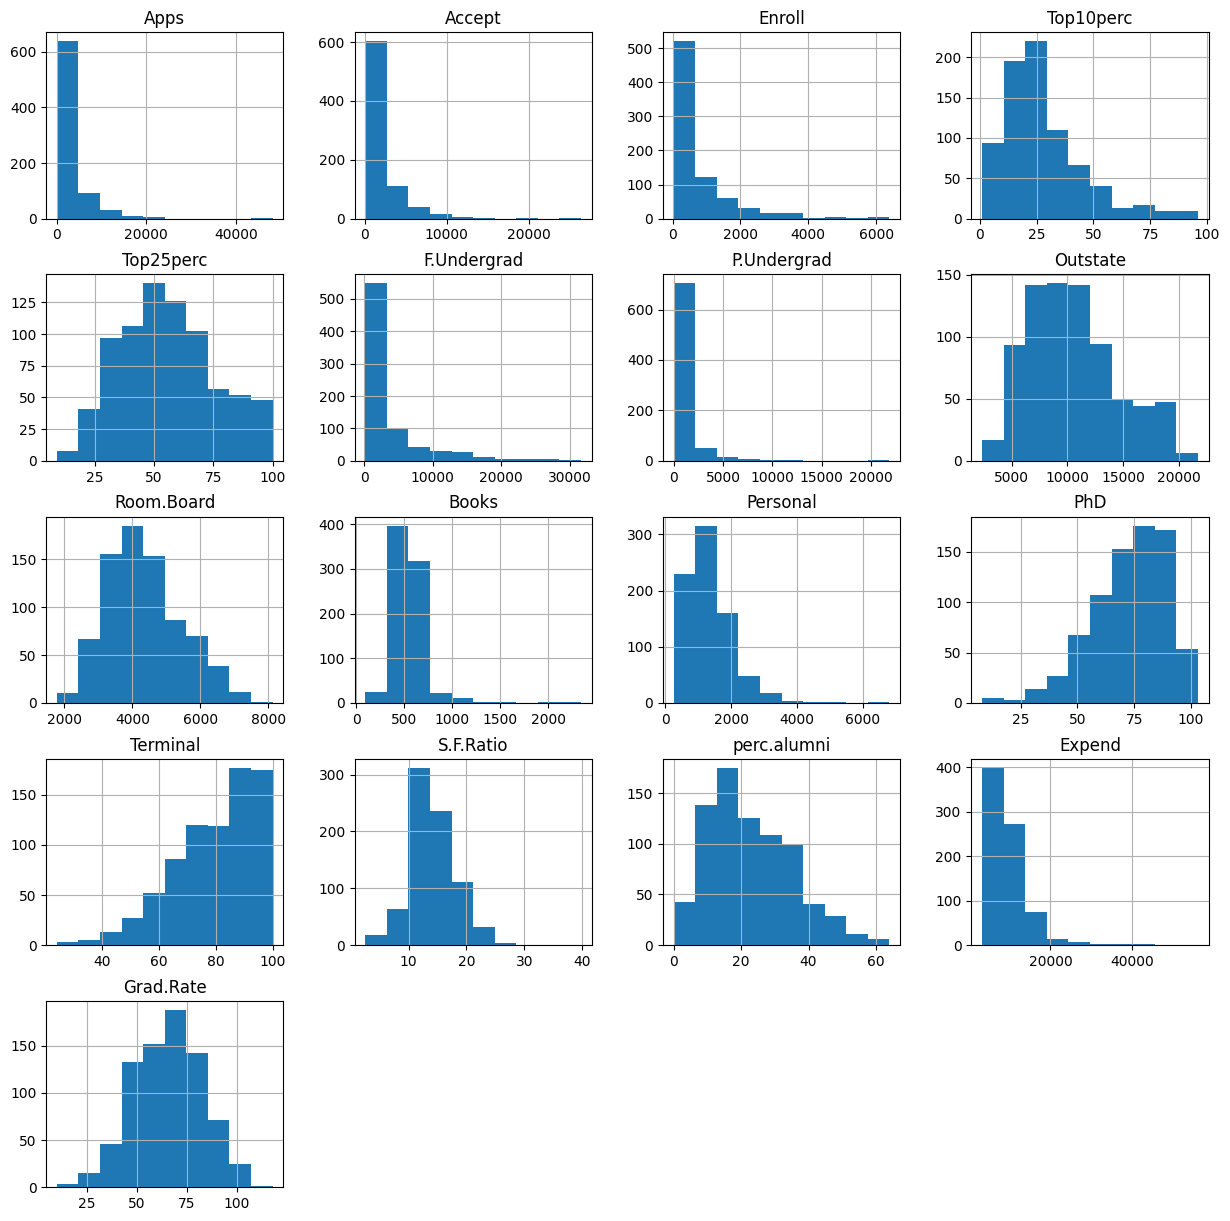

In [ ]:
import matplotlib.pyplot as plt 

quant_columns = college.columns[2:-1]

df_temp = college.select(quant_columns).to_pandas()

df_temp.hist(figsize=(15, 15))

plt.show()

del df_temp, quant_columns

I have skipped questions 9 and 10 in the interest of time. They involve simple exploratory data analysis tasks. I have experience doing similar analyses in the past and am confident in my ability to solve them. I might return to them later.